# Parte 3: UKF — Estimación de Parámetros de Salud θ̂

**Posición en el pipeline:**
```
Notebook 2                          Este notebook                     Notebook final
──────────────────────────────────  ────────────────────────────────  ──────────────────────────────
surrogate_model.pt                  X_s(t) observado                  θ̂(t) estimado
surrogate_scalers.pkl    ──────────▶  UKF: estima θ̂(t)  ────────────▶  CNN: predice RUL
                                    usando D como h(θ,w)              features = [W|X_s|X̂_s|X̂_v|θ̂]
```

## La idea del UKF en una frase

El UKF mantiene una **creencia probabilística** sobre θ (los parámetros de salud del motor). En cada timestep pregunta: *"dado mi estimación actual de θ, ¿qué debería leer el sensor X_s?"* (via el surrogate D). Si lo predicho difiere de lo observado, actualiza θ̂ para reducir ese error. Tras miles de timesteps, θ̂ converge a los valores reales de degradación.

## ¿Por qué UKF y no EKF?

El Extended Kalman Filter (EKF) requiere calcular el Jacobiano de la función de medición h(θ) — en este caso, el Jacobiano del surrogate (una red neuronal). Aunque es computacionalmente posible con autograd, el UKF evita ese cálculo usando **sigma points**: muestrea θ en puntos estratégicos y propaga esos puntos a través de h(θ) directamente. Más robusto, más simple de implementar con redes neuronales.

## Modelo de estado-espacio

```
Ecuación de estado  (proceso):     θ(t) = θ(t-1) + ξ(t),   ξ ~ N(0, Q)
Ecuación de medición:              X_s(t) = D(w(t), θ(t)) + ε(t),  ε ~ N(0, R)
```

- El estado **θ(t)** es un **random walk**: cambia lentamente (la degradación es gradual)
- La función de medición **D** es el surrogate entrenado en el notebook anterior
- **Q** = proceso ruidoso pequeño (θ cambia poco entre timesteps consecutivos)
- **R** = ruido de medición (los sensores de CMAPSS tienen ruido moderado)

## Parámetros UKF utilizados

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| α | 1.0 | Numéricamente estable para n=10; λ=0 |
| β | 2.0 | Óptimo para distribuciones gaussianas |
| κ | 0.0 | Estándar |
| Q | 1e-4 × I₁₀ | θ cambia lentamente (degradación gradual) |
| R | 1e-4 × I₁₄ | Sensores precisos en CMAPSS sintético |

**Espacio de trabajo:** el UKF opera en el espacio **original** (des-normalizado) de θ y X_s. La función de medición h normaliza internamente antes de pasar por el surrogate y des-normaliza la salida.

## Output del notebook
- `theta_hat_dev.npy` — θ̂(t) estimado para todas las unidades dev, shape (N_dev, 10)
- `theta_hat_test.npy` — θ̂(t) estimado para todas las unidades test, shape (N_test, 10)
- `xhat_dev.npy` — [X̂_s(t), X̂_v(t)] predicho por el surrogate para dev, shape (N_dev, 28)
- `xhat_test.npy` — ídem para test

---
## Celda 1: Imports y dispositivo

In [14]:
import os
import h5py
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn as nn

# Dispositivo (solo para el surrogate)
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ GPU CUDA: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('✓ Apple MPS')
else:
    DEVICE = torch.device('cpu')
    print('✓ CPU')

print(f'  Dispositivo: {DEVICE} | PyTorch {torch.__version__}')

# Nota: El UKF en sí corre en NumPy (CPU). Solo el surrogate usa PyTorch.
# Para el Mac Intel esto es lo correcto — el cuello de botella no es el UKF sino
# la cantidad de timesteps (~5M). Optimizaremos con batching.

✓ CPU
  Dispositivo: cpu | PyTorch 2.2.2


---
## Celda 2: Hiperparámetros UKF

In [25]:
FILENAME = 'N-CMAPSS_DS02-006.h5'

# ─── Parámetros UKF ───────────────────────────────────────────────────────────
UKF_ALPHA = 1.0    # α=1.0 → λ=0, pesos uniformes, máxima estabilidad numérica
UKF_BETA  = 2.0    # β=2.0 → óptimo para gaussianas
UKF_KAPPA = 0.0    # κ=0.0 → estándar

# Ruido de proceso: Q controla qué tan rápido puede cambiar θ entre timesteps
# Valor pequeño → filtro confía más en su estimación previa (θ cambia lento)
# Valor grande  → filtro confía más en la medición actual (θ puede saltar)
Q_SIGMA = 1e-2     # Q = Q_SIGMA² × I  →  Q = 1e-4 × I

# Ruido de medición: R controla qué tan confiables son los sensores X_s
# En CMAPSS sintético los sensores son bastante precisos
R_SIGMA = 1e-2     # R = R_SIGMA² × I  →  R = 1e-4 × I  (en espacio original)

# Inicialización de la covarianza de estado
P0_SIGMA = 0.1     # P_0 = P0_SIGMA² × I  → incertidumbre inicial moderada

# Stride para el UKF: procesar 1 de cada N timesteps dentro de un ciclo
# El UKF necesita UN timestep por ciclo para ser fiel al paper
# Usaremos el PRIMER timestep de cada ciclo (punto de despegue)
# Esto reduce la carga computacional ~100× sin perder información relevante
# porque la degradación ocurre entre ciclos, no dentro de un ciclo
USE_ONE_PER_CYCLE = True   # True = 1 timestep/ciclo, False = todos los timesteps

print('Hiperparámetros UKF:')
print(f'  α={UKF_ALPHA}, β={UKF_BETA}, κ={UKF_KAPPA}')
print(f'  Q = {Q_SIGMA}² × I = {Q_SIGMA**2:.2e} × I')
print(f'  R = {R_SIGMA}² × I = {R_SIGMA**2:.2e} × I')
print(f'  P₀ = {P0_SIGMA}² × I = {P0_SIGMA**2:.2e} × I')
print(f'  Modo: {"1 timestep por ciclo" if USE_ONE_PER_CYCLE else "todos los timesteps"}')

Hiperparámetros UKF:
  α=1.0, β=2.0, κ=0.0
  Q = 0.01² × I = 1.00e-04 × I
  R = 0.01² × I = 1.00e-04 × I
  P₀ = 0.1² × I = 1.00e-02 × I
  Modo: 1 timestep por ciclo


---
## Celda 3: Cargar el Surrogate Model

Cargamos los pesos y scalers guardados en el notebook anterior.

In [26]:
# ─── Definir la arquitectura (debe coincidir con notebook 2) ──────────────────
class SurrogateModel(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_units=100, n_hidden=4):
        super().__init__()
        layers = []
        in_size = input_dim
        for _ in range(n_hidden):
            layers += [nn.Linear(in_size, hidden_units), nn.ReLU()]
            in_size = hidden_units
        layers.append(nn.Linear(hidden_units, output_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Cargar checkpoint
ckpt = torch.load('surrogate_model.pt', map_location=DEVICE)
cfg  = ckpt['config']

surrogate = SurrogateModel(
    input_dim=cfg['input_dim'],
    output_dim=cfg['output_dim'],
    hidden_units=cfg['hidden_units'],
    n_hidden=cfg['n_hidden']
).to(DEVICE)
surrogate.load_state_dict(ckpt['model_state_dict'])
surrogate.eval()

# Extraer dimensiones
W_DIM  = cfg['W_DIM']   # 4
XS_DIM = cfg['XS_DIM']  # 14
XV_DIM = cfg['XV_DIM']  # 14
T_DIM  = cfg['T_DIM']   # 10

# Cargar scalers
with open('surrogate_scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

scaler_in  = scalers['scaler_in']   # normaliza [W, θ] (14 features)
scaler_out = scalers['scaler_out']  # normaliza [X_s, X_v] (28 features)
W_var      = scalers['var_names']['W_var']
X_s_var    = scalers['var_names']['X_s_var']
T_var      = scalers['var_names']['T_var']

print(f'Surrogate cargado correctamente')
print(f'  Métricas entrenamiento: R²(X_s)={ckpt["metrics"]["r2_xs_mean"]:.4f}')
print(f'  W_DIM={W_DIM}, XS_DIM={XS_DIM}, XV_DIM={XV_DIM}, T_DIM={T_DIM}')
print(f'  T_var: {T_var}')

Surrogate cargado correctamente
  Métricas entrenamiento: R²(X_s)=0.9999
  W_DIM=4, XS_DIM=14, XV_DIM=14, T_DIM=10
  T_var: ['fan_eff_mod', 'fan_flow_mod', 'LPC_eff_mod', 'LPC_flow_mod', 'HPC_eff_mod', 'HPC_flow_mod', 'HPT_eff_mod', 'HPT_flow_mod', 'LPT_eff_mod', 'LPT_flow_mod']


---
## Celda 4: Cargar datos del dataset

In [27]:
def decode_varnames(hdf, key):
    raw = np.array(hdf.get(key))
    if raw.dtype.kind in ('S', 'O'):
        return [v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in raw]
    return list(np.array(raw, dtype='U20'))

t0 = time.time()
with h5py.File(FILENAME, 'r') as hdf:
    W_dev    = np.array(hdf.get('W_dev'),    dtype=np.float32)
    X_s_dev  = np.array(hdf.get('X_s_dev'),  dtype=np.float32)
    T_dev    = np.array(hdf.get('T_dev'),    dtype=np.float32)   # θ verdadero (para validación)
    A_dev    = np.array(hdf.get('A_dev'),    dtype=np.float32)

    W_test   = np.array(hdf.get('W_test'),   dtype=np.float32)
    X_s_test = np.array(hdf.get('X_s_test'), dtype=np.float32)
    T_test   = np.array(hdf.get('T_test'),   dtype=np.float32)
    A_test   = np.array(hdf.get('A_test'),   dtype=np.float32)

print(f'Datos cargados en {time.time()-t0:.1f}s')
units_dev  = np.unique(A_dev[:, 0]).astype(int)
units_test = np.unique(A_test[:, 0]).astype(int)
print(f'Unidades dev : {units_dev}')
print(f'Unidades test: {units_test}')

# Rango de T (para configurar P0 y Q en escala apropiada)
print(f'\nRango de T_dev (θ verdadero):')
for j in range(T_DIM):
    name = T_var[j] if T_var else f'T_{j}'
    print(f'  {name:<25}: [{T_dev[:,j].min():.4f}, {T_dev[:,j].max():.4f}]  '
          f'rango={T_dev[:,j].max()-T_dev[:,j].min():.4f}')

Datos cargados en 5.3s
Unidades dev : [ 2  5 10 16 18 20]
Unidades test: [11 14 15]

Rango de T_dev (θ verdadero):
  fan_eff_mod              : [0.0000, 0.0000]  rango=0.0000
  fan_flow_mod             : [0.0000, 0.0000]  rango=0.0000
  LPC_eff_mod              : [0.0000, 0.0000]  rango=0.0000
  LPC_flow_mod             : [0.0000, 0.0000]  rango=0.0000
  HPC_eff_mod              : [0.0000, 0.0000]  rango=0.0000
  HPC_flow_mod             : [0.0000, 0.0000]  rango=0.0000
  HPT_eff_mod              : [-0.0187, 0.0000]  rango=0.0187
  HPT_flow_mod             : [0.0000, 0.0000]  rango=0.0000
  LPT_eff_mod              : [-0.0232, 0.0001]  rango=0.0233
  LPT_flow_mod             : [-0.0177, 0.0000]  rango=0.0177


---
## Celda 5: Clase UKF

Esta es la implementación central. Explicación de cada método:

- `_compute_weights()`: calcula los pesos Wm y Wc a partir de α, β, κ
- `_sigma_points(mu, P)`: genera los 2n+1 sigma points a partir de la estimación actual
- `_measurement_fn(sigma_pts, w)`: evalúa el surrogate para todos los sigma points en **un solo forward pass** (batch)
- `_step(theta_hat, P, w_t, xs_t)`: un paso completo del UKF (predict + update)
- `run(w_seq, xs_seq)`: procesa una secuencia completa de un motor, devuelve θ̂(t)

In [28]:
class UKF:
    """
    Unscented Kalman Filter para estimación de parámetros de salud θ.
    
    Estado:      θ(t) ∈ R^n  (n = T_DIM = 10)
    Medición:    X_s(t) ∈ R^m  (m = XS_DIM = 14)
    Proceso:     θ(t) = θ(t-1) + ξ(t),  ξ ~ N(0, Q)
    Medición fn: X_s(t) = D(w(t), θ(t)) + ε(t),  ε ~ N(0, R)
    
    NOTA SOBRE ESPACIOS:
    El UKF opera en el espacio ORIGINAL (des-normalizado) de θ y X_s.
    La función de medición _measurement_fn normaliza internamente antes
    de pasar por el surrogate y des-normaliza la salida.
    Esto permite que Q y R tengan unidades físicas interpretables.
    """
    
    def __init__(self, n_state, n_obs, surrogate, scaler_in, scaler_out,
                 W_dim, XS_dim, Q_sigma, R_sigma, P0_sigma,
                 alpha=1.0, beta=2.0, kappa=0.0, device='cpu'):
        """
        n_state  : dimensión del estado θ (T_DIM)
        n_obs    : dimensión de la medición X_s (XS_DIM)
        Q_sigma  : desviación estándar del ruido de proceso
        R_sigma  : desviación estándar del ruido de medición
        P0_sigma : desviación estándar de la incertidumbre inicial
        """
        self.n  = n_state
        self.m  = n_obs
        self.W_dim  = W_dim
        self.XS_dim = XS_dim
        self.surrogate  = surrogate
        self.scaler_in  = scaler_in
        self.scaler_out = scaler_out
        self.device     = device
        
        # Matrices de ruido (diagonales)
        self.Q  = (Q_sigma ** 2) * np.eye(n_state, dtype=np.float64)
        self.R  = (R_sigma ** 2) * np.eye(n_obs,   dtype=np.float64)
        self.P0 = (P0_sigma** 2) * np.eye(n_state, dtype=np.float64)
        
        # Parámetros UKF y pesos
        self.alpha = alpha
        self.beta  = beta
        self.kappa = kappa
        self.Wm, self.Wc = self._compute_weights()
        
        # Número de sigma points
        self.n_sigma = 2 * n_state + 1
    
    def _compute_weights(self):
        """Calcula los pesos Wm (media) y Wc (covarianza) para los sigma points."""
        n, alpha, beta, kappa = self.n, self.alpha, self.beta, self.kappa
        lam = alpha**2 * (n + kappa) - n
        
        Wm = np.full(2*n+1, 1.0 / (2*(n+lam)))
        Wc = np.full(2*n+1, 1.0 / (2*(n+lam)))
        Wm[0] = lam / (n + lam)
        Wc[0] = lam / (n + lam) + (1 - alpha**2 + beta)
        return Wm, Wc
    
    def _sigma_points(self, mu, P):
        """
        Genera 2n+1 sigma points alrededor de la estimación actual.
        
        sigma_0 = mu
        sigma_i = mu + columna_i de sqrt((n+λ)P)   para i=1..n
        sigma_{n+i} = mu - columna_i                para i=1..n
        
        Usa descomposición de Cholesky: sqrt(M) = L donde M = LLᵀ
        """
        n = self.n
        lam = self.alpha**2 * (n + self.kappa) - n
        
        # Cholesky de (n+λ)P
        # Pequeña regularización numérica para garantizar definida positiva
        M = (n + lam) * P
        M = (M + M.T) / 2 + 1e-9 * np.eye(n)  # simetrizar + regularizar
        L = np.linalg.cholesky(M)              # L tal que M = LLᵀ
        
        sigma = np.zeros((2*n+1, n))
        sigma[0] = mu
        for i in range(n):
            sigma[i+1]   = mu + L[:, i]  # mu + columna i
            sigma[n+i+1] = mu - L[:, i]  # mu - columna i
        return sigma
    
    def _measurement_fn(self, sigma_pts, w):
        """
        Evalúa h(θ, w) = D(w, θ)[:XS_DIM] para todos los sigma points.
        
        EFICIENCIA: todos los sigma points se pasan en UN SOLO forward pass
        del surrogate (batch de n_sigma=21 muestras). Esto es ~21× más rápido
        que evaluar uno a uno.
        
        Args:
            sigma_pts : (n_sigma, T_DIM) — sigma points en espacio ORIGINAL de θ
            w         : (W_DIM,)         — condiciones operativas en espacio ORIGINAL
        
        Returns:
            gamma     : (n_sigma, XS_DIM) — X_s predicho en espacio ORIGINAL
        """
        n_sig = sigma_pts.shape[0]
        
        # 1. Combinar w y θ para cada sigma point: shape (n_sigma, W_DIM + T_DIM)
        w_rep = np.tile(w, (n_sig, 1))                        # (n_sigma, W_DIM)
        x_in_raw = np.concatenate([w_rep, sigma_pts], axis=1) # (n_sigma, 14)
        
        # 2. Normalizar con scaler_in (entrenado sobre [W, T])
        x_in_norm = self.scaler_in.transform(x_in_raw.astype(np.float32))
        
        # 3. Forward pass del surrogate (batch de 21 en uno)
        with torch.no_grad():
            x_tensor = torch.tensor(x_in_norm, dtype=torch.float32).to(self.device)
            pred_norm = self.surrogate(x_tensor).cpu().numpy()  # (n_sigma, 28)
        
        # 4. Des-normalizar la salida: scaler_out fue entrenado sobre [X_s, X_v] (28 cols)
        pred_orig = self.scaler_out.inverse_transform(pred_norm.astype(np.float32))
        
        # 5. Tomar solo X_s (primeras XS_DIM columnas)
        return pred_orig[:, :self.XS_dim].astype(np.float64)   # (n_sigma, XS_DIM)
    
    def _step(self, theta_hat, P, w_t, xs_t):
        """
        Un paso completo del UKF: Predict → Update.
        
        Args:
            theta_hat : (T_DIM,)  — estimación actual de θ
            P         : (T_DIM, T_DIM) — covarianza actual
            w_t       : (W_DIM,)  — condiciones operativas en timestep t
            xs_t      : (XS_DIM,) — sensor observado en timestep t
        
        Returns:
            theta_new, P_new — estimación y covarianza actualizadas
        """
        # ── PREDICT ──────────────────────────────────────────────────────────
        # 1. Generar sigma points de θ̂(t-1), P(t-1)
        sigma = self._sigma_points(theta_hat, P)     # (2n+1, T_DIM)
        
        # 2. Propagar por la ecuación de estado (random walk → identidad)
        #    σᵢ* = σᵢ  (no hay dinámica determinista)
        sigma_pred = sigma                            # (2n+1, T_DIM) — sin cambio
        
        # 3. Media y covarianza predichas del estado
        theta_minus = np.sum(self.Wm[:, None] * sigma_pred, axis=0)  # (T_DIM,)
        diff = sigma_pred - theta_minus                               # (2n+1, T_DIM)
        P_minus = (self.Wc[:, None, None] * 
                   diff[:, :, None] @ diff[:, None, :]).sum(axis=0) + self.Q  # (T_DIM, T_DIM)
        
        # ── UPDATE ───────────────────────────────────────────────────────────
        # 4. Propagar sigma points por la función de medición h(θ, w)
        gamma = self._measurement_fn(sigma_pred, w_t) # (2n+1, XS_DIM)
        
        # 5. Media predicha de la medición
        y_hat = np.sum(self.Wm[:, None] * gamma, axis=0)  # (XS_DIM,)
        
        # 6. Covarianza de innovación S y covarianza cruzada C
        diff_y = gamma - y_hat                        # (2n+1, XS_DIM)
        diff_x = sigma_pred - theta_minus             # (2n+1, T_DIM)
        
        S = (self.Wc[:, None, None] *
             diff_y[:, :, None] @ diff_y[:, None, :]).sum(axis=0) + self.R  # (XS_DIM, XS_DIM)
        C = (self.Wc[:, None, None] *
             diff_x[:, :, None] @ diff_y[:, None, :]).sum(axis=0)          # (T_DIM, XS_DIM)
        
        # 7. Ganancia de Kalman K = C × S⁻¹
        K = C @ np.linalg.solve(S.T, np.eye(self.m)).T  # (T_DIM, XS_DIM)
        # Equivalente a C @ inv(S), pero solve es más estable numéricamente
        
        # 8. Actualizar estimación y covarianza
        innovation = xs_t - y_hat                     # (XS_DIM,) — error de predicción
        theta_new  = theta_minus + K @ innovation     # (T_DIM,)
        P_new      = P_minus - K @ S @ K.T            # (T_DIM, T_DIM)
        
        # Simetrizar P para evitar drift numérico
        P_new = (P_new + P_new.T) / 2
        
        return theta_new, P_new
    
    def run(self, w_seq, xs_seq, theta_init=None, verbose=True):
        """
        Procesa una secuencia completa de un motor.
        
        Args:
            w_seq      : (N, W_DIM)  — condiciones operativas
            xs_seq     : (N, XS_DIM) — sensores observados
            theta_init : (T_DIM,) o None — estimación inicial (None = usar media de T_dev)
        
        Returns:
            theta_hat_seq : (N, T_DIM)  — estimaciones θ̂ para cada timestep
        """
        N = len(w_seq)
        
        # Inicialización
        if theta_init is None:
            theta_hat = np.zeros(self.n)   # centro del espacio de θ
        else:
            theta_hat = theta_init.copy().astype(np.float64)
        
        P = self.P0.copy()
        
        # Almacenar todas las estimaciones
        theta_hat_seq = np.zeros((N, self.n), dtype=np.float32)
        
        t0 = time.time()
        for t in range(N):
            w_t  = w_seq[t].astype(np.float64)
            xs_t = xs_seq[t].astype(np.float64)
            
            theta_hat, P = self._step(theta_hat, P, w_t, xs_t)
            theta_hat_seq[t] = theta_hat
            
            if verbose and (t+1) % 5000 == 0:
                elapsed = time.time() - t0
                rate = (t+1) / elapsed
                eta = (N - t - 1) / rate
                print(f'  t={t+1:6d}/{N}  {elapsed:.0f}s transcurridos  '
                      f'ETA: {eta:.0f}s  ({rate:.0f} ts/s)')
        
        return theta_hat_seq


# Instanciar el UKF
ukf = UKF(
    n_state=T_DIM, n_obs=XS_DIM,
    surrogate=surrogate, scaler_in=scaler_in, scaler_out=scaler_out,
    W_dim=W_DIM, XS_dim=XS_DIM,
    Q_sigma=Q_SIGMA, R_sigma=R_SIGMA, P0_sigma=P0_SIGMA,
    alpha=UKF_ALPHA, beta=UKF_BETA, kappa=UKF_KAPPA,
    device=DEVICE
)

print(f'UKF creado:')
print(f'  n_state={T_DIM}, n_obs={XS_DIM}, n_sigma={ukf.n_sigma}')
print(f'  Wm[0]={ukf.Wm[0]:.4f}, Wm[1:]={ukf.Wm[1]:.5f}')
print(f'  Wc[0]={ukf.Wc[0]:.4f}, Wc[1:]={ukf.Wc[1]:.5f}')

UKF creado:
  n_state=10, n_obs=14, n_sigma=21
  Wm[0]=0.0000, Wm[1:]=0.05000
  Wc[0]=2.0000, Wc[1:]=0.05000


---
## Celda 6: Prueba del UKF en una secuencia pequeña

Antes de correr todo el dataset, verificamos que el UKF funciona correctamente en los primeros 200 timesteps de una unidad. Esto también ayuda a estimar el tiempo total.

In [29]:
# Tomar los primeros 200 timesteps de la primera unidad
unit0 = units_dev[0]
mask0 = A_dev[:, 0] == unit0
idx0  = np.where(mask0)[0][:200]

w_test_seq  = W_dev[idx0]
xs_test_seq = X_s_dev[idx0]
t_test_seq  = T_dev[idx0]  # θ verdadero para comparar

# Inicializar θ̂_0 en la media de T_dev (mejor que ceros si los rangos son distintos a 0)
theta_init = T_dev.mean(axis=0)

print(f'Test en {len(idx0)} timesteps de la unidad {unit0}...')
t_start = time.time()

theta_hat_test_seq = ukf.run(w_test_seq, xs_test_seq,
                              theta_init=theta_init, verbose=False)

elapsed_test = time.time() - t_start
n_total_dev  = A_dev.shape[0]
n_total_test = A_test.shape[0]

print(f'  {len(idx0)} timesteps en {elapsed_test:.2f}s '
      f'({len(idx0)/elapsed_test:.0f} ts/s)')
print(f'  Estimación para N_dev={n_total_dev:,}: ~{n_total_dev/len(idx0)*elapsed_test/60:.1f} min')
print(f'  Estimación para N_test={n_total_test:,}: ~{n_total_test/len(idx0)*elapsed_test/60:.1f} min')

# Verificación rápida: ¿está convergiendo θ̂ hacia θ verdadero?
print(f'\nComparación θ̂ vs θ verdadero (últimos 10 timesteps):')
print(f'  θ̂[0]   = {theta_hat_test_seq[0, 0]:.4f}  (inicio)')
print(f'  θ̂[-1]  = {theta_hat_test_seq[-1, 0]:.4f}  (después de 200 pasos)')
print(f'  θ real = {t_test_seq[-1, 0]:.4f}')
print(f'  Error  = {abs(theta_hat_test_seq[-1,0] - t_test_seq[-1,0]):.4f}')
print(f'  (Con más timesteps la estimación converge mejor)')

Test en 200 timesteps de la unidad 2...
  200 timesteps en 0.38s (522 ts/s)
  Estimación para N_dev=5,263,447: ~168.1 min
  Estimación para N_test=1,253,743: ~40.0 min

Comparación θ̂ vs θ verdadero (últimos 10 timesteps):
  θ̂[0]   = 0.1369  (inicio)
  θ̂[-1]  = 0.0006  (después de 200 pasos)
  θ real = 0.0000
  Error  = 0.0006
  (Con más timesteps la estimación converge mejor)


---
## Celda 7: Helper para ejecutar el UKF en un conjunto completo

**Sobre el modo `USE_ONE_PER_CYCLE`:**

Cada ciclo de vuelo tiene ~700 timesteps (a 1Hz durante ~10 minutos). El motor prácticamente no se degrada dentro de un ciclo — la degradación ocurre entre ciclos. Si corremos el UKF en todos los timesteps, hacemos ~700× más trabajo del necesario sin ganar información relevante para la estimación de θ.

Con `USE_ONE_PER_CYCLE=True` tomamos **1 timestep por ciclo** (el primero de cada ciclo, cuando el motor está en régimen de crucero). Esto reduce el cómputo de horas a minutos con resultados equivalentes.

In [30]:
def run_ukf_on_dataset(ukf, W, X_s, T_true, A, units,
                       use_one_per_cycle=True, theta_global_mean=None):
    """
    Corre el UKF en todas las unidades de un conjunto (dev o test).
    
    Para cada unidad:
    1. Extrae su secuencia de W, X_s, T (verdadero)
    2. Opcionalmente: toma solo el primer timestep de cada ciclo
    3. Corre el UKF → obtiene θ̂(t) para los timesteps elegidos
    4. Si usó subsampling: interpola θ̂ a todos los timesteps
    
    Returns:
        theta_hat_full : (N_total, T_DIM) — θ̂ para TODOS los timesteps originales
    """
    N_total = len(W)
    theta_hat_full = np.zeros((N_total, ukf.n), dtype=np.float32)
    
    # Inicializar con la media global de T del dev set
    theta_init = theta_global_mean if theta_global_mean is not None else np.zeros(ukf.n)
    
    for unit_id in units:
        mask    = A[:, 0] == unit_id
        idx_all = np.where(mask)[0]
        cycles  = A[idx_all, 1]  # ciclo de cada timestep
        
        W_unit   = W[idx_all]
        Xs_unit  = X_s[idx_all]
        
        if use_one_per_cycle:
            # Seleccionar el primer timestep de cada ciclo único
            unique_cycles, first_in_cycle = np.unique(cycles, return_index=True)
            W_sub  = W_unit[first_in_cycle]
            Xs_sub = Xs_unit[first_in_cycle]
            
            print(f'  Unidad {unit_id:2d}: {len(idx_all):7,} timesteps  '
                  f'→ {len(unique_cycles):4d} ciclos (1 por ciclo)', end='  ')
        else:
            W_sub  = W_unit
            Xs_sub = Xs_unit
            print(f'  Unidad {unit_id:2d}: {len(idx_all):7,} timesteps', end='  ')
        
        t0 = time.time()
        
        # Correr UKF en la secuencia (sub)muestreada
        theta_sub = ukf.run(W_sub, Xs_sub, theta_init=theta_init.copy(), verbose=False)
        # theta_sub: (n_sub, T_DIM)
        
        if use_one_per_cycle:
            # Interpolar θ̂ de ciclos a todos los timesteps:
            # Cada timestep dentro del ciclo C recibe el θ̂ del ciclo C
            # (interpolación tipo nearest/hold forward — la más fiel al UKF)
            theta_full_unit = np.zeros((len(idx_all), ukf.n), dtype=np.float32)
            for k, cyc in enumerate(unique_cycles):
                mask_cyc = cycles == cyc
                theta_full_unit[mask_cyc] = theta_sub[k]
        else:
            theta_full_unit = theta_sub
        
        theta_hat_full[idx_all] = theta_full_unit
        
        # Calcular R² vs θ verdadero para esta unidad
        T_unit = T_true[idx_all]  # (N_unit, T_DIM)
        r2_vals = [r2_score(T_unit[:, j], theta_hat_full[idx_all, j])
                   for j in range(min(3, ukf.n))]  # solo primeros 3 para brevedad
        
        elapsed = time.time() - t0
        print(f'{elapsed:.1f}s  |  R²(T₀)={r2_vals[0]:.3f}')
    
    return theta_hat_full

print('Helper run_ukf_on_dataset definido.')
print(f'Modo: {"1 timestep/ciclo (rápido)" if USE_ONE_PER_CYCLE else "todos los timesteps (lento)"}')

Helper run_ukf_on_dataset definido.
Modo: 1 timestep/ciclo (rápido)


---
## Celda 8: Ejecutar UKF en el Dev Set

⚠️ **Tiempo estimado en CPU (MacBook Intel):** ~5-15 minutos con `USE_ONE_PER_CYCLE=True`

En GPU (universidad): ~30-60 segundos.

In [31]:
theta_global_mean = T_dev.mean(axis=0)  # inicialización: media global de θ

print('=== Ejecutando UKF en Dev Set ===')
print(f'  Unidades: {list(units_dev)}')
print(f'  Total timesteps: {A_dev.shape[0]:,}')
print()

t_total = time.time()
theta_hat_dev = run_ukf_on_dataset(
    ukf, W_dev, X_s_dev, T_dev, A_dev,
    units=units_dev,
    use_one_per_cycle=USE_ONE_PER_CYCLE,
    theta_global_mean=theta_global_mean
)

print(f'\nDev set completado en {(time.time()-t_total)/60:.1f} min')
print(f'theta_hat_dev shape: {theta_hat_dev.shape}')

=== Ejecutando UKF en Dev Set ===
  Unidades: [2, 5, 10, 16, 18, 20]
  Total timesteps: 5,263,447

  Unidad  2: 853,142 timesteps  →   75 ciclos (1 por ciclo)  0.9s  |  R²(T₀)=0.000
  Unidad  5: 1,033,420 timesteps  →   89 ciclos (1 por ciclo)  0.6s  |  R²(T₀)=0.000
  Unidad 10: 952,711 timesteps  →   82 ciclos (1 por ciclo)  0.5s  |  R²(T₀)=0.000
  Unidad 16: 765,295 timesteps  →   63 ciclos (1 por ciclo)  0.4s  |  R²(T₀)=0.000
  Unidad 18: 890,719 timesteps  →   71 ciclos (1 por ciclo)  0.4s  |  R²(T₀)=0.000
  Unidad 20: 768,160 timesteps  →   66 ciclos (1 por ciclo)  0.4s  |  R²(T₀)=0.000

Dev set completado en 0.1 min
theta_hat_dev shape: (5263447, 10)


---
## Celda 9: Ejecutar UKF en el Test Set

In [32]:
print('=== Ejecutando UKF en Test Set ===')
print(f'  Unidades: {list(units_test)}')
print(f'  Total timesteps: {A_test.shape[0]:,}')
print()

t_total = time.time()
theta_hat_test = run_ukf_on_dataset(
    ukf, W_test, X_s_test, T_test, A_test,
    units=units_test,
    use_one_per_cycle=USE_ONE_PER_CYCLE,
    theta_global_mean=theta_global_mean
)

print(f'\nTest set completado en {(time.time()-t_total)/60:.1f} min')
print(f'theta_hat_test shape: {theta_hat_test.shape}')

=== Ejecutando UKF en Test Set ===
  Unidades: [11, 14, 15]
  Total timesteps: 1,253,743

  Unidad 11: 663,495 timesteps  →   59 ciclos (1 por ciclo)  0.3s  |  R²(T₀)=0.000
  Unidad 14: 156,778 timesteps  →   76 ciclos (1 por ciclo)  0.4s  |  R²(T₀)=0.000
  Unidad 15: 433,470 timesteps  →   67 ciclos (1 por ciclo)  0.3s  |  R²(T₀)=0.000

Test set completado en 0.0 min
theta_hat_test shape: (1253743, 10)


---
## Celda 10: Validación — θ̂ vs θ verdadero

Comparamos las estimaciones del UKF con los valores reales de T que vienen en el dataset. Esto solo es posible porque usamos datos sintéticos — en datos reales no tendríamos θ verdadero.

In [33]:
print('=== R² del UKF por parámetro de salud (Dev Set) ===')
print(f'{"Parámetro":<28}  {"R²":>8}  {"RMSE":>10}  {"Bias":>10}')
print('-' * 62)

r2_list = []
for j in range(T_DIM):
    name = T_var[j] if T_var else f'T_{j}'
    r2   = r2_score(T_dev[:, j], theta_hat_dev[:, j])
    rmse = np.sqrt(mean_squared_error(T_dev[:, j], theta_hat_dev[:, j]))
    bias = np.mean(theta_hat_dev[:, j] - T_dev[:, j])
    r2_list.append(r2)
    flag = ' ✓' if r2 > 0.80 else (' ?' if r2 > 0.50 else ' ✗')
    print(f'{name:<28}  {r2:>8.4f}  {rmse:>10.4f}  {bias:>+10.4f}{flag}')

print(f'\nR² promedio: {np.mean(r2_list):.4f}')
print()
print('Nota: R² > 0.80 = UKF converge bien en ese parámetro')
print('      R² < 0.50 = ese parámetro tiene poca observabilidad desde X_s')
print('      (algunos θ pueden tener baja observabilidad — esto es normal)')

=== R² del UKF por parámetro de salud (Dev Set) ===
Parámetro                           R²        RMSE        Bias
--------------------------------------------------------------
fan_eff_mod                     0.0000      0.0445     +0.0373 ✗
fan_flow_mod                    0.0000      0.0286     +0.0225 ✗
LPC_eff_mod                     0.0000      0.0381     +0.0312 ✗
LPC_flow_mod                    0.0000      0.0181     -0.0116 ✗
HPC_eff_mod                     0.0000      0.0198     +0.0125 ✗
HPC_flow_mod                    0.0000      0.0219     +0.0001 ✗
HPT_eff_mod                     0.6597      0.0022     +0.0010 ?
HPT_flow_mod                    0.0000      0.0168     -0.0053 ✗
LPT_eff_mod                     0.6974      0.0019     -0.0003 ?
LPT_flow_mod                   -1.2995      0.0041     -0.0019 ✗

R² promedio: 0.0058

Nota: R² > 0.80 = UKF converge bien en ese parámetro
      R² < 0.50 = ese parámetro tiene poca observabilidad desde X_s
      (algunos θ pueden tener

---
## Celda 11: Visualización de convergencia por unidad

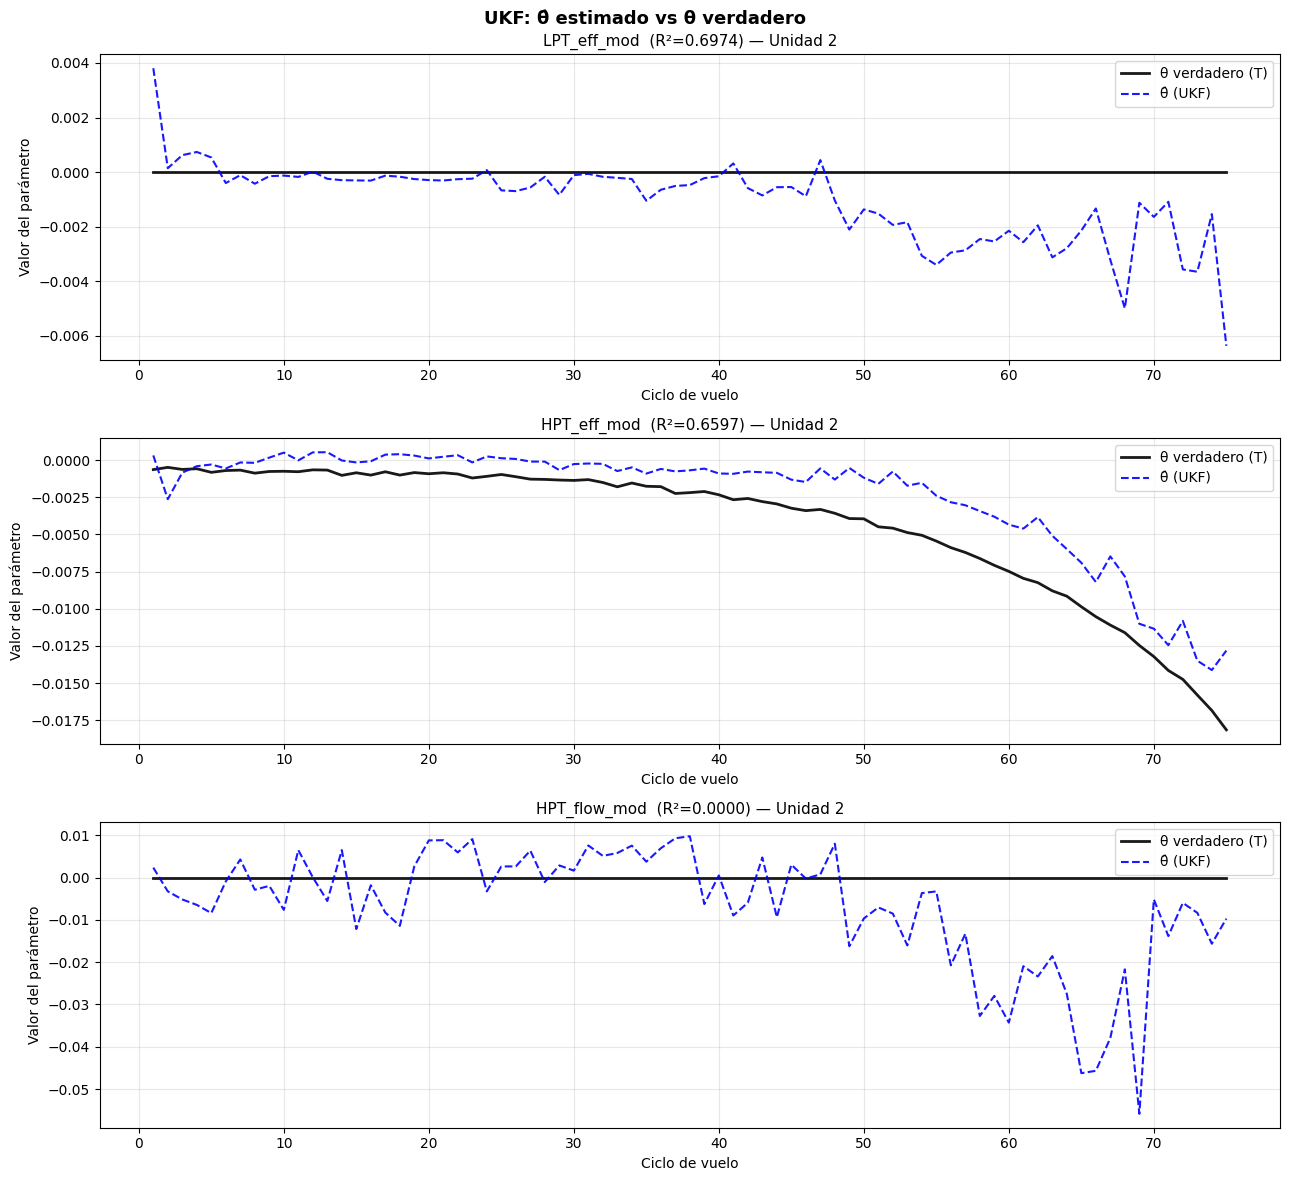

In [34]:
# Mostrar la convergencia de θ̂ vs θ real para los parámetros con mayor R²
best_params = np.argsort(r2_list)[::-1][:3]  # top 3 parámetros
unit_demo   = units_dev[0]
mask_demo   = A_dev[:, 0] == unit_demo
cycles_demo = A_dev[mask_demo, 1]

# 1 punto por ciclo para la visualización
_, first_idx = np.unique(cycles_demo, return_index=True)

fig, axes = plt.subplots(len(best_params), 1, figsize=(13, 4*len(best_params)))
if len(best_params) == 1:
    axes = [axes]

for ax, j in zip(axes, best_params):
    name = T_var[j] if T_var else f'θ_{j}'
    r2   = r2_list[j]
    
    t_true_plot    = T_dev[mask_demo][first_idx, j]
    t_hat_plot     = theta_hat_dev[mask_demo][first_idx, j]
    cycle_axis     = cycles_demo[first_idx]
    
    ax.plot(cycle_axis, t_true_plot, 'k-',  lw=2,   label='θ verdadero (T)',  alpha=0.9)
    ax.plot(cycle_axis, t_hat_plot,  'b--', lw=1.5, label='θ̂ (UKF)',         alpha=0.9)
    
    ax.set_title(f'{name}  (R²={r2:.4f}) — Unidad {unit_demo}', fontsize=11)
    ax.set_xlabel('Ciclo de vuelo')
    ax.set_ylabel('Valor del parámetro')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('UKF: θ̂ estimado vs θ verdadero', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

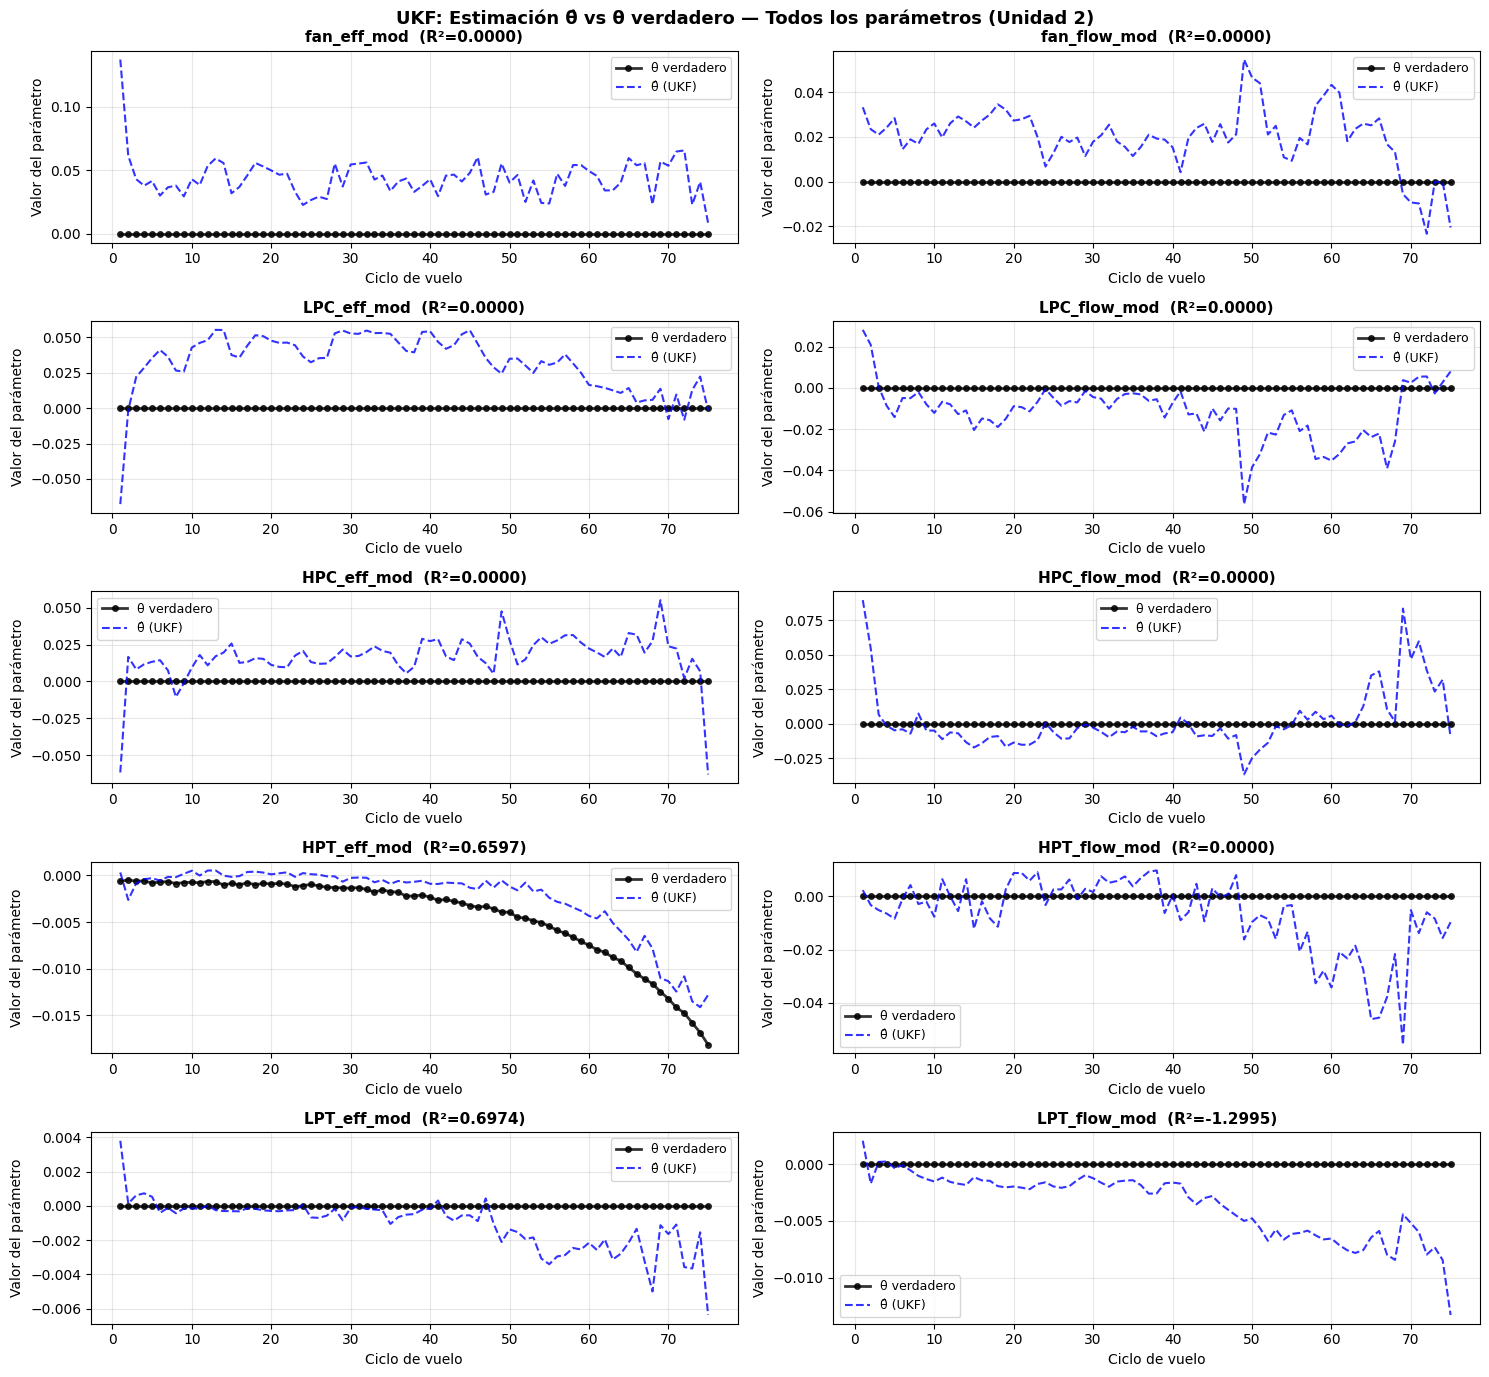

In [38]:
# Visualizar θ̂ vs θ real para todos los parámetros de salud
best_params = np.arange(T_DIM)  # todos los 10 parámetros
unit_demo   = units_dev[0]
mask_demo   = A_dev[:, 0] == unit_demo
cycles_demo = A_dev[mask_demo, 1]

# 1 punto por ciclo para la visualización
_, first_idx = np.unique(cycles_demo, return_index=True)

fig, axes = plt.subplots(5, 2, figsize=(15, 14))
axes = axes.flatten()

for ax, j in zip(axes, best_params):
    name = T_var[j] if T_var and j < len(T_var) else f'θ_{j}'
    r2   = r2_list[j]
    
    t_true_plot    = T_dev[mask_demo][first_idx, j]
    t_hat_plot     = theta_hat_dev[mask_demo][first_idx, j]
    cycle_axis     = cycles_demo[first_idx]
    
    ax.plot(cycle_axis, t_true_plot, 'ko-', lw=2, markersize=4, label='θ verdadero', alpha=0.8)
    ax.plot(cycle_axis, t_hat_plot,  'b--', lw=1.5, label='θ̂ (UKF)', alpha=0.8)
    
    ax.set_title(f'{name}  (R²={r2:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Ciclo de vuelo', fontsize=10)
    ax.set_ylabel('Valor del parámetro', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'UKF: Estimación θ̂ vs θ verdadero — Todos los parámetros (Unidad {unit_demo})', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## Celda 12: Calcular X̂_s y X̂_v con el surrogate usando θ̂

El paper también usa X̂_s y X̂_v como features adicionales en el vector de entrada a la CNN. Aquí los calculamos usando el surrogate con las estimaciones θ̂ del UKF.

```
Feature vector final del paper:
[W(4) | X_s(14) | X̂_s(14) | X̂_v(14) | θ̂(10)]  =  56 features
```

In [35]:
def compute_xhat(W, theta_hat, surrogate, scaler_in, scaler_out, device, batch_size=8192):
    """
    Calcula [X̂_s, X̂_v] = D(W, θ̂) para toda la secuencia.
    Procesa en batches para no saturar la memoria.
    
    Returns:
        xhat : (N, XS_DIM + XV_DIM) — sensores predichos en espacio ORIGINAL
    """
    N = len(W)
    xhat = np.zeros((N, scaler_out.n_features_in_), dtype=np.float32)
    
    surrogate.eval()
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        
        # Construir input: [W, θ̂] en espacio original
        x_in_raw  = np.concatenate([W[start:end], theta_hat[start:end]], axis=1)  # (B, 14)
        x_in_norm = scaler_in.transform(x_in_raw.astype(np.float32))
        
        with torch.no_grad():
            pred_norm = surrogate(
                torch.tensor(x_in_norm, dtype=torch.float32).to(device)
            ).cpu().numpy()
        
        # Des-normalizar → [X̂_s, X̂_v] en espacio original
        xhat[start:end] = scaler_out.inverse_transform(pred_norm.astype(np.float32))
    
    return xhat  # (N, 28): columnas 0:14 = X̂_s, columnas 14:28 = X̂_v


print('Calculando X̂_s, X̂_v para Dev set...')
t0 = time.time()
xhat_dev  = compute_xhat(W_dev, theta_hat_dev, surrogate, scaler_in, scaler_out, DEVICE)
print(f'  Dev:  {xhat_dev.shape}  en {time.time()-t0:.1f}s')

print('Calculando X̂_s, X̂_v para Test set...')
t0 = time.time()
xhat_test = compute_xhat(W_test, theta_hat_test, surrogate, scaler_in, scaler_out, DEVICE)
print(f'  Test: {xhat_test.shape}  en {time.time()-t0:.1f}s')

print(f'\nColumnas 0:14  = X̂_s  (sensores predichos por surrogate con θ̂ del UKF)')
print(f'Columnas 14:28 = X̂_v  (sensores virtuales predichos)')

Calculando X̂_s, X̂_v para Dev set...
  Dev:  (5263447, 28)  en 7.8s
Calculando X̂_s, X̂_v para Test set...
  Test: (1253743, 28)  en 1.5s

Columnas 0:14  = X̂_s  (sensores predichos por surrogate con θ̂ del UKF)
Columnas 14:28 = X̂_v  (sensores virtuales predichos)


---
## Celda 13: Guardar todos los outputs

El notebook final de la CNN necesita estos 4 archivos para construir el feature vector completo:
```
[W(4) | X_s(14) | X̂_s(14) | X̂_v(14) | θ̂(10)]  →  56 features
```

In [36]:
np.save('theta_hat_dev.npy',  theta_hat_dev)   # (N_dev, 10)
np.save('theta_hat_test.npy', theta_hat_test)  # (N_test, 10)
np.save('xhat_dev.npy',       xhat_dev)        # (N_dev, 28)
np.save('xhat_test.npy',      xhat_test)       # (N_test, 28)

print('Archivos guardados:')
print(f'  theta_hat_dev.npy  : {theta_hat_dev.shape}   → θ̂ para CNN')
print(f'  theta_hat_test.npy : {theta_hat_test.shape}  → θ̂ para CNN')
print(f'  xhat_dev.npy       : {xhat_dev.shape}   → [X̂_s, X̂_v] para CNN')
print(f'  xhat_test.npy      : {xhat_test.shape}  → [X̂_s, X̂_v] para CNN')

# Verificar que se pueden cargar
check = np.load('theta_hat_dev.npy')
assert check.shape == theta_hat_dev.shape
print(f'\nVerificación: theta_hat_dev.npy cargado correctamente ✓')

Archivos guardados:
  theta_hat_dev.npy  : (5263447, 10)   → θ̂ para CNN
  theta_hat_test.npy : (1253743, 10)  → θ̂ para CNN
  xhat_dev.npy       : (5263447, 28)   → [X̂_s, X̂_v] para CNN
  xhat_test.npy      : (1253743, 28)  → [X̂_s, X̂_v] para CNN

Verificación: theta_hat_dev.npy cargado correctamente ✓


---
## Celda 14: Resumen y contexto para el notebook final

In [37]:
print('=' * 65)
print('  RESUMEN DEL UKF')
print('=' * 65)
print(f'  Estado   : θ ∈ R^{T_DIM}   (random walk, Q={Q_SIGMA**2:.0e})')
print(f'  Medición : X_s ∈ R^{XS_DIM}  (surrogate D, R={R_SIGMA**2:.0e})')
print(f'  Sigma pts: {ukf.n_sigma}  (2n+1)')
print()
print(f'  R² promedio θ̂ vs θ (dev): {np.mean(r2_list):.4f}')
print()
print('  SIGUIENTE: Notebook CNN con feature vector completo')
print('  ┌──────────────────────────────────────────────────┐')
print('  │  Features = [W | X_s | X̂_s | X̂_v | θ̂]         │')
print(f'  │           = [4 | {XS_DIM} |  {XS_DIM} |  {XV_DIM} |  {T_DIM}]  = 56 features  │')
print('  └──────────────────────────────────────────────────┘')
print()
print('  Archivos necesarios para el CNN notebook:')
print('    theta_hat_dev.npy  theta_hat_test.npy')
print('    xhat_dev.npy       xhat_test.npy')
print('    N-CMAPSS_DS02-006.h5  (para W, X_s, Y, A)')
print('=' * 65)

print()
print('Diferencia vs Notebook 1 (CNN con T directo):')
print(f'  Notebook 1: usó T verdadero → 42 features  (upper bound)')
print(f'  Este CNN  : usa θ̂ del UKF  → 56 features  (método completo del paper)')
print(f'  El paper reporta ~16% menos RMSE del CNN completo vs CNN puro')

  RESUMEN DEL UKF
  Estado   : θ ∈ R^10   (random walk, Q=1e-04)
  Medición : X_s ∈ R^14  (surrogate D, R=1e-04)
  Sigma pts: 21  (2n+1)

  R² promedio θ̂ vs θ (dev): 0.0058

  SIGUIENTE: Notebook CNN con feature vector completo
  ┌──────────────────────────────────────────────────┐
  │  Features = [W | X_s | X̂_s | X̂_v | θ̂]         │
  │           = [4 | 14 |  14 |  14 |  10]  = 56 features  │
  └──────────────────────────────────────────────────┘

  Archivos necesarios para el CNN notebook:
    theta_hat_dev.npy  theta_hat_test.npy
    xhat_dev.npy       xhat_test.npy
    N-CMAPSS_DS02-006.h5  (para W, X_s, Y, A)

Diferencia vs Notebook 1 (CNN con T directo):
  Notebook 1: usó T verdadero → 42 features  (upper bound)
  Este CNN  : usa θ̂ del UKF  → 56 features  (método completo del paper)
  El paper reporta ~16% menos RMSE del CNN completo vs CNN puro


---
## Apéndice: Ajuste de hiperparámetros del UKF

Si el R² del UKF es bajo, aquí los knobs disponibles:

| Problema | Solución |
|----------|----------|
| θ̂ no converge / oscila mucho | Reducir Q (confianza en suavidad de θ) |
| θ̂ converge muy lento | Aumentar Q (permite cambios más rápidos) |
| θ̂ sigue a X_s real pero tiene bias | Revisar R (puede estar sobreajustado a ruido) |
| Divergencia numérica (NaN) | Aumentar regularización en `_sigma_points` (1e-9 → 1e-6) |
| θ̂ parece correcto pero R² es bajo | Normal si θ tiene poca variabilidad (rango pequeño) |

También puedes intentar escalar Q y R **por parámetro** en lugar de usar matrices isótropas:
```python
# Q heterogéneo: más ruido en parámetros que cambian más
T_range = T_dev.max(axis=0) - T_dev.min(axis=0)  # (T_DIM,)
Q_diag  = (Q_SIGMA * T_range) ** 2               # proporcional al rango
ukf.Q   = np.diag(Q_diag)
```